In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.4 MB/s eta 0:00:00


In [ ]:
!pip install iterative-stratification

In [ ]:
import os
import glob
import shutil
import numpy as np
import yaml
import matplotlib.pyplot as plt
import torch
from ultralytics import YOLO
from google.colab import drive
from sklearn.model_selection import train_test_split
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 1. 압축 해제 (최신 완료본 파일명 반영)
zip_path = '/content/drive/MyDrive/tuk_YOLO_data/tuk_objects_completed_final.zip'
extract_dir = '/content/dataset/'

if os.path.exists(extract_dir):
    shutil.rmtree(extract_dir)

print("🚀 1단계: 원본 스타일로 초고속 압축 해제 시작...")
!unzip -qo "{zip_path}" -d "{extract_dir}"
print("✅ 압축 해제가 완료되었습니다!")

🚀 1단계: 원본 스타일로 초고속 압축 해제 시작...
✅ 압축 해제가 완료되었습니다!


📸 원본 이미지 총 38526장 발견
✂️ 10프레임 스킵 적용 후 추출된 이미지: 3853장

📊 데이터 분할 완료 (이미지 수 기준)
  - Train (학습용)    : 3082장
  - Val   (검증용)    : 385장
  - Test  (최종평가용) : 386장
✅ train.txt / val.txt / test.txt 생성 완료
✅ data.yaml 설정 파일 생성 완료

📊 각 클래스별 8:1:1 분할 비율 정밀 검증
  - [elevator          ] Train: 80.6% | Val:  9.3% | Test: 10.2% (총 443개)
  - [vending_machine   ] Train: 79.9% | Val: 10.0% | Test: 10.0% (총 428개)
  - [trash_bin         ] Train: 80.3% | Val:  9.8% | Test:  9.9% (총 523개)
  - [self_service_cafe ] Train: 80.1% | Val:  9.9% | Test:  9.9% (총 151개)
  - [water_dispenser   ] Train: 79.9% | Val: 10.1% | Test: 10.1% (총 288개)
  - [locker            ] Train: 80.0% | Val:  9.8% | Test: 10.2% (총 215개)
  - [door              ] Train: 79.9% | Val:  9.8% | Test: 10.2% (총 1056개)
  - [cabinet           ] Train: 79.9% | Val: 10.1% | Test: 10.1% (총 318개)
  - [photo_copier      ] Train: 78.8% | Val: 10.0% | Test: 11.2% (총 160개)
  - [person            ] Train: 81.2% | Val:  8.4% | Test: 10.4% (총 642개)
  - [lectern 

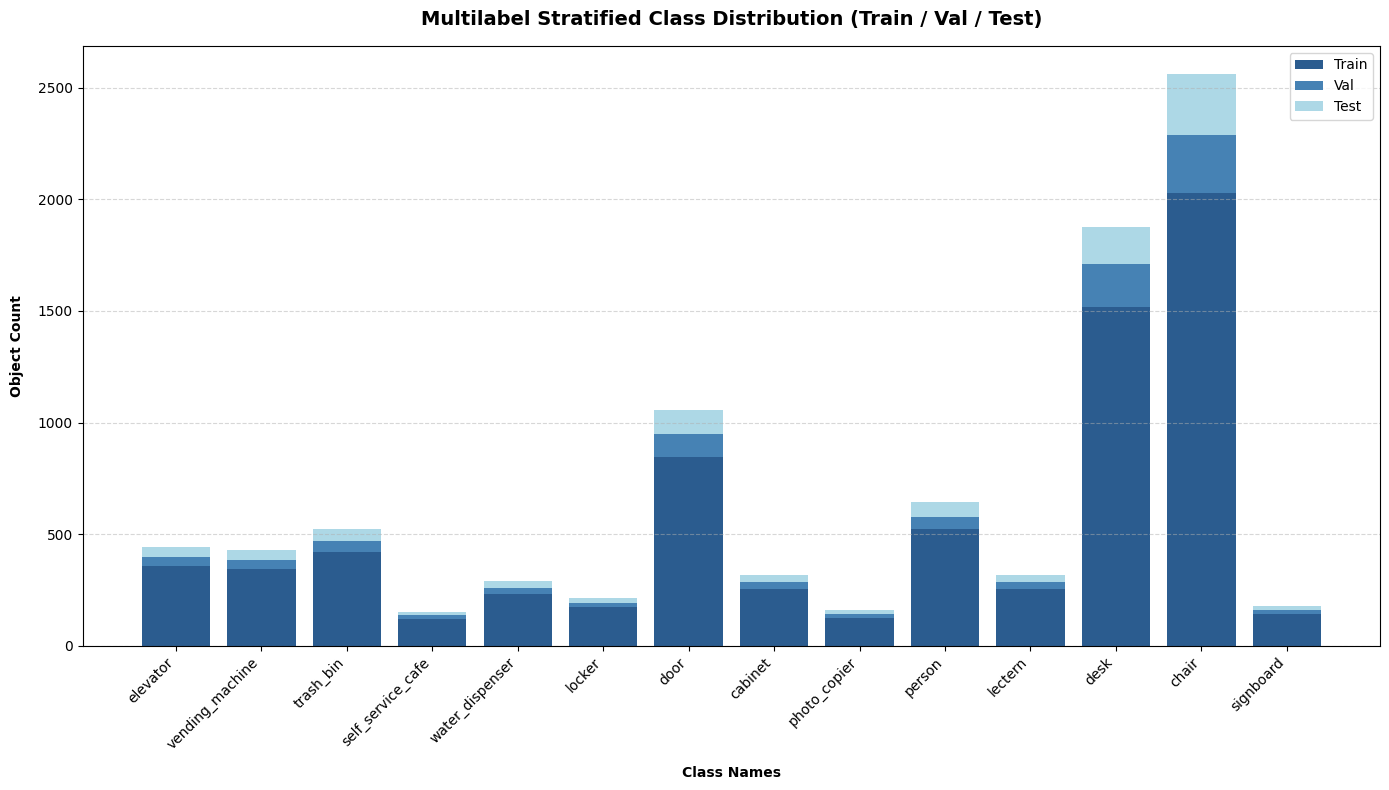

📈 클래스 비율 분포 그래프 출력 및 저장 완료

🚀 학습 사용 디바이스: 0
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer

In [ ]:
# 2. 이미지 및 라벨 경로 자동 탐색
image_dir = '/content/dataset/train/images/'
image_files = sorted(glob.glob(os.path.join(image_dir, '*.png')))

# 1순위 경로에 없으면 2순위 표준 경로 체크
if len(image_files) == 0:
    image_dir = '/content/dataset/images/train/'
    image_files = sorted(glob.glob(os.path.join(image_dir, '*.png')))

# 최종 경로 확인 예외 처리
if len(image_files) == 0:
    print("❌ 이미지를 찾을 수 없습니다. 현재 폴더 구조를 확인하세요.")
    if os.path.exists('/content/dataset/'):
        print(os.listdir('/content/dataset/'))
else:
    print(f"📸 원본 이미지 총 {len(image_files)}장 발견")

    # 3. 데이터 다이어트 (정확히 10프레임당 1장 추출 확인)
    selected_images = image_files[::10]
    print(f"✂️ 10프레임 스킵 적용 후 추출된 이미지: {len(selected_images)}장")

    # 4. 클래스 정의 및 원-핫 인코딩 행렬(Y) 생성
    class_names = [
        'elevator', 'vending_machine', 'trash_bin', 'self_service_cafe',
        'water_dispenser', 'locker', 'door', 'cabinet', 'photo_copier',
        'person', 'lectern', 'desk', 'chair', 'signboard'
    ]
    nc = len(class_names)

    X = np.array(selected_images)
    Y = np.zeros((len(selected_images), nc))

    # 이미지별 라벨 파싱하여 존재하는 클래스 표시 (경로 치환 버그 예방 안전 코드 적용)
    for i, img_path in enumerate(selected_images):
        if 'train/images/' in img_path:
            label_path = img_path.replace('train/images/', 'train/labels/').replace('.png', '.txt')
        else:
            label_path = img_path.replace('/images/', '/labels/').replace('.png', '.txt')

        if not os.path.exists(label_path):
            continue

        with open(label_path, 'r') as f:
            for line in f:
                if not line.strip():
                    continue
                cls = int(line.split()[0])
                if cls < nc:
                    Y[i, cls] = 1  # 멀티라벨 인덱스 세팅

    # 5. 다중라벨 계층 분할 (Multilabel Stratified Shuffle Split) - 8:1:1
    msss1 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, temp_idx = next(msss1.split(X, Y))

    train_imgs = X[train_idx]
    temp_imgs = X[temp_idx]
    temp_Y = Y[temp_idx]

    msss2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
    val_idx, test_idx = next(msss2.split(temp_imgs, temp_Y))

    val_imgs = temp_imgs[val_idx]
    test_imgs = temp_imgs[test_idx]

    print("\n📊 데이터 분할 완료 (이미지 수 기준)")
    print(f"  - Train (학습용)    : {len(train_imgs)}장")
    print(f"  - Val   (검증용)    : {len(val_imgs)}장")
    print(f"  - Test  (최종평가용) : {len(test_imgs)}장")

    # 6. YOLO 포맷 경로 지정을 위한 txt 파일 저장
    def save_txt(path, img_list):
        with open(path, 'w') as f:
            for img_path in img_list:
                f.write(os.path.abspath(img_path) + '\n')

    save_txt('/content/dataset/train.txt', train_imgs)
    save_txt('/content/dataset/val.txt', val_imgs)
    save_txt('/content/dataset/test.txt', test_imgs)
    print("✅ train.txt / val.txt / test.txt 생성 완료")

    # 7. data.yaml 환경 설정 파일 생성
    data_config = {
        'train': '/content/dataset/train.txt',
        'val': '/content/dataset/val.txt',
        'test': '/content/dataset/test.txt',
        'nc': nc,
        'names': class_names
    }

    with open('/content/dataset/data.yaml', 'w') as f:
        yaml.dump(data_config, f, default_flow_style=False)
    print("✅ data.yaml 설정 파일 생성 완료")

    # 8. 실제 분할셋별 객체 빈도수 카운트 함수 (경로 안전 매핑 완료)
    def count_classes(img_list):
        counts = [0] * nc
        for img_path in img_list:
            if 'train/images/' in img_path:
                label_path = img_path.replace('train/images/', 'train/labels/').replace('.png', '.txt')
            else:
                label_path = img_path.replace('/images/', '/labels/').replace('.png', '.txt')

            if not os.path.exists(label_path):
                continue

            with open(label_path, 'r') as f:
                for line in f:
                    if line.strip():
                        cls = int(line.split()[0])
                        if cls < nc:
                            counts[cls] += 1
        return counts

    train_counts = count_classes(train_imgs)
    val_counts = count_classes(val_imgs)
    test_counts = count_classes(test_imgs)

    # 9. 클래스 분할 비율 터미널 출력 및 검증
    print("\n📊 각 클래스별 8:1:1 분할 비율 정밀 검증")
    for i, name in enumerate(class_names):
        total = train_counts[i] + val_counts[i] + test_counts[i]
        if total == 0:
            continue
        print(f"  - [{name:18s}] Train:{train_counts[i]/total*100:5.1f}% | Val:{val_counts[i]/total*100:5.1f}% | Test:{test_counts[i]/total*100:5.1f}% (총 {total}개)")

    # 10. Matplotlib 활용 누적 막대 그래프 시각화
    x = np.arange(nc)
    plt.figure(figsize=(14, 8))

    plt.bar(x, train_counts, label='Train', color='#2b5c8f')
    plt.bar(x, val_counts, bottom=train_counts, label='Val', color='#4682b4')
    plt.bar(x, test_counts, bottom=np.array(train_counts) + np.array(val_counts), label='Test', color='#add8e6')

    plt.xticks(x, class_names, rotation=45, ha='right')
    plt.xlabel('Class Names', fontweight='bold', labelpad=10)
    plt.ylabel('Object Count', fontweight='bold', labelpad=10)
    plt.title('Multilabel Stratified Class Distribution (Train / Val / Test)', fontsize=14, fontweight='bold', pad=15)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.savefig('/content/dataset/class_distribution_ratio.png', dpi=300)
    plt.show()
    print("📈 클래스 비율 분포 그래프 출력 및 저장 완료")

    # 11. 디바이스 자동 체크 및 YOLOv8 모델 학습 시작
    selected_device = 0 if torch.cuda.is_available() else 'cpu'
    print(f"\n🚀 학습 사용 디바이스: {selected_device}")

    model = YOLO('yolov8n.pt')
    model.train(
        data='/content/dataset/data.yaml',
        epochs=100,
        imgsz=640,
        patience=20,
        device=selected_device
    )